# Dummy Classifier
Selects the most frequent class - No Cancellation

In [1]:
import os
import sys
from sklearn.dummy import DummyClassifier
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.model_utils import (
    load_encoded_splits,
    evaluate_classifier,
    plot_metric_scorecards,
    get_confusion_matrix_df,
    plot_roc_curve
)

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 103), y_train: (60876,)
X_val:   (13045, 103), y_val:   (13045,)
X_test:  (13046, 103), y_test:  (13046,)


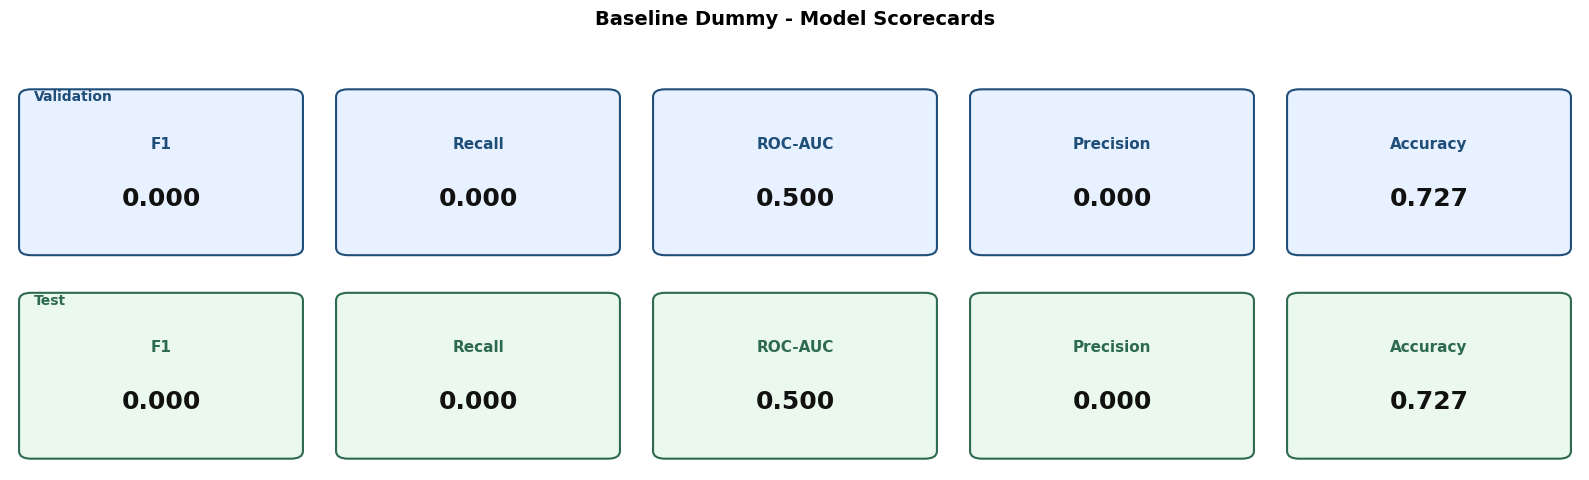

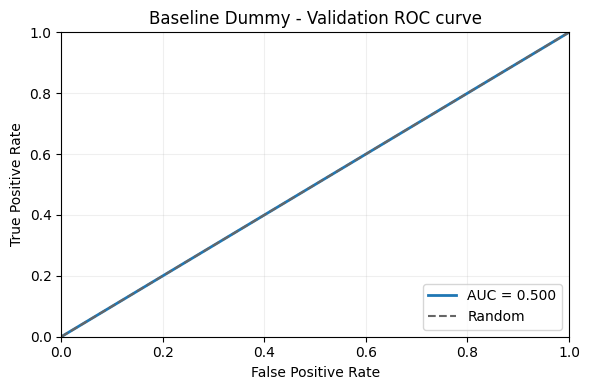

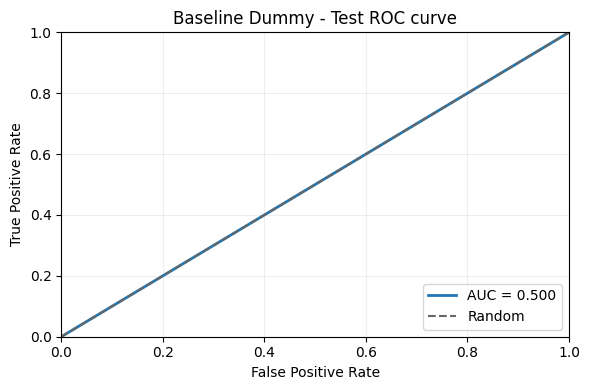

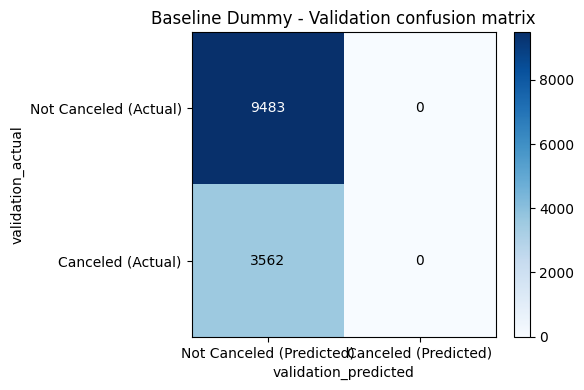

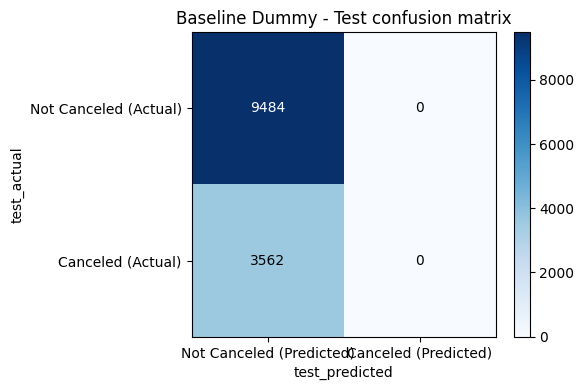

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.7269,0.0,0.0,0.0,0.5
1,test,0.7270,0.0,0.0,0.0,0.5


In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

model = DummyClassifier(strategy="most_frequent", random_state=42)
model.fit(X_train, y_train)

val_results = evaluate_classifier(model, X_val, y_val, 'validation')
test_results = evaluate_classifier(model, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results, notebook_name='04_baseline_dummy.ipynb')
plot_roc_curve(model, X_val, y_val, 'validation', notebook_name='04_baseline_dummy.ipynb')
plot_roc_curve(model, X_test, y_test, 'test', notebook_name='04_baseline_dummy.ipynb')
val_cm = get_confusion_matrix_df(model, X_val, y_val, 'validation', notebook_name='04_baseline_dummy.ipynb', plot=True)
test_cm = get_confusion_matrix_df(model, X_test, y_test, 'test', notebook_name='04_baseline_dummy.ipynb', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))